# Analysis of paired short- and long-read dataset

Analyzing data from [Zajac et al. 2025](https://doi.org/10.1093/nargab/lqaf089)

In [1]:
from collections import defaultdict
import os
import sys
import glob
import re
import numpy as np
import pandas as pd
from scipy import sparse, stats
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from matplotlib import pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
import scvelo as scv
from itertools import combinations
import warnings

In [2]:
def reverse_complement(sequence: str):
    complement_dict = defaultdict(lambda: "N", {"A": "T", "C": "G", "G": "C", "T": "A"})
    rc = ""
    for base in sequence[::-1]:
        rc += complement_dict[base]
    return rc

In [3]:
# Create figure and output directories
DATA_DIR = "../data/zajac"
FIG_DIR = "../figures/zajac"
OUT_DIR = "../out/zajac"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
def summarize_isoform_adata_by_gene(adata: sc.AnnData, classifications: pd.DataFrame):
    # Add isoform classifications to AnnData object
    adata_copy = adata.copy()
    adata_copy.var[["pacbio_id", "gene_name"]] = adata.var["gene_ids"].str.split(":", expand=True)
    classifications = classifications[["isoform", "chrom", "strand", "structural_category", "exons", "ref_exons"]]
    adata_copy.var = adata_copy.var.reset_index().merge(
        classifications, left_on="pacbio_id", right_on="isoform", how="left"
    ).set_index("index")

    # Remove unknown genes, fusions, etc.
    adata_copy = adata_copy[:, ~adata_copy.var["structural_category"].isin(
        ["antisense", "intergenic", "fusion", "moreJunctions"]
    )]
    adata_copy = adata_copy[:, ~adata_copy.var["gene_name"].str.contains("\+")]

    # Annotate spliced/unspliced based on structural isoform category
    adata_copy.var["structural_category_"] = (
        adata_copy.var["structural_category"] + 
        adata_copy.var["ref_exons"].fillna(0).astype(int).astype(str)
    )
    adata_copy.var["splice_state"] = (
        adata_copy.var["structural_category"].isin(["genic", "genic_intron"]) &
        (adata_copy.var["structural_category_"] != "genic1")
    ).map({True: "unspliced", False: "spliced"})

    # Sum up spliced and unspliced counts per gene
    adata_agg = sc.get.aggregate(adata_copy, by=["gene_name", "splice_state"], func="sum", axis="var")
    adata_spliced = adata_agg[:, adata_agg.var["splice_state"] == "spliced"]
    adata_unspliced = adata_agg[:, adata_agg.var["splice_state"] == "unspliced"]
    adata_spliced.var = adata_spliced.var.set_index("gene_name")
    adata_unspliced.var = adata_unspliced.var.set_index("gene_name")

    # Construct new var data frame
    all_var_names = pd.Index(sorted(set(adata_spliced.var_names).union(adata_unspliced.var_names)))
    var = pd.DataFrame(
        index=pd.Index(all_var_names)
    ).reset_index().merge(
        adata_copy.var[["gene_name", "chrom", "strand"]], left_on="index", right_on="gene_name", how="left"
    ).set_index("index").drop_duplicates(subset="gene_name")

    # Create count matrices
    spliced = pd.DataFrame(
        np.zeros((adata_agg.n_obs, len(all_var_names))), index=adata_agg.obs_names, columns=all_var_names
    )
    spliced.loc[:, adata_spliced.var_names] = adata_spliced.layers["sum"]
    unspliced = pd.DataFrame(
        np.zeros((adata_agg.n_obs, len(all_var_names))), index=adata_agg.obs_names, columns=all_var_names
    )
    unspliced.loc[:, adata_unspliced.var_names] = adata_unspliced.layers["sum"]

    # Create new AnnData object
    adata_new = sc.AnnData(
        sparse.csr_matrix(spliced.values + unspliced.values),
        obs=adata_agg.obs,
        var=var,
        layers={
            "spliced": sparse.csr_matrix(spliced.values),
            "unspliced": sparse.csr_matrix(unspliced.values),
        },
    )

    return adata_new

In [5]:
def summarize_gene_adata_by_gene(adata: sc.AnnData):
    adata_copy = adata.copy()
    adata_copy.var[["pacbio_id", "gene_name"]] = adata.var["gene_ids"].str.split(":", expand=True)
    adata_copy.var = adata_copy.var.drop(columns="pacbio_id")

    # Sum up counts per gene
    adata_agg = sc.get.aggregate(adata_copy, by="gene_name", func="sum", axis="var")
    adata_agg.X = sparse.csr_matrix(adata_agg.layers["sum"])
    del adata_agg.layers["sum"]
    return adata_agg

In [6]:
# Load the data
# Cell Ranger and velocyto: Need to make genes unique before merging
adatas_cr = {
    re.search("/cellranger/filtered/(.*)/outs", file).group(1): sc.read_10x_h5(file)
    for file in glob.glob(
        os.path.join(DATA_DIR, "cellranger/filtered/*/outs/raw_feature_bc_matrix.h5")
    )
}
for adata in adatas_cr.values():
    adata.var_names_make_unique()
    
adatas_velo = {
    re.search("/cellranger/filtered/(.*)/velocyto", file).group(1): sc.read_loom(file)
    for file in glob.glob(os.path.join(DATA_DIR, "cellranger/filtered/*/velocyto/*.loom"))
}
for adata in adatas_velo.values():
    adata.var_names_make_unique()

adatas_pb = {
    re.search("/pacbio/filtered/(.*)/matrices/isoforms_seurat", folder).group(1): sc.read_10x_mtx(folder)
    for folder in glob.glob(
        os.path.join(DATA_DIR, "pacbio/filtered/*/matrices/isoforms_seurat")
    )    
}
isoform_classifications = {
    re.search("/pacbio/filtered/(.*)/", file).group(1): pd.read_csv(file, sep="\t")
    for file in glob.glob(
        os.path.join(DATA_DIR, "pacbio/filtered/*/scisoseq_classification.txt")
    ) 
}
for adata in adatas_pb.values():
    adata.obs_names = adata.obs_names.str.strip("-1").map(reverse_complement) + "-1"
adatas_pb_summarized = {
    sample: summarize_isoform_adata_by_gene(adata, isoform_classifications[sample])
    for sample, adata in adatas_pb.items()
}

adatas_pb_gene = {
    re.search("/pacbio/filtered/(.*)/matrices/genes_seurat", folder).group(1): sc.read_10x_mtx(folder)
    for folder in glob.glob(
        os.path.join(DATA_DIR, "pacbio/filtered/*/matrices/genes_seurat")
    )    
}
for adata in adatas_pb_gene.values():
    adata.obs_names = adata.obs_names.str.strip("-1").map(reverse_complement) + "-1"
adatas_pb_gene_summarized = {
    sample: summarize_gene_adata_by_gene(adata)
    for sample, adata in adatas_pb_gene.items()
}

adatas = {
    "velocyto": ad.concat(
        adatas_velo, index_unique="_", join="outer", merge="same", label="sample"
    ),
    "alevin-fry": ad.concat(
        {
            re.search("/alevin/(.*)/quant_res", file).group(1): sc.read_h5ad(file)
            for file in glob.glob(os.path.join(DATA_DIR, "alevin/*/quant_res/adata.h5ad"))
        }, index_unique="_", join="outer", merge="same", label="sample"
    ),
    "tidesurf": ad.concat(
        {
            re.search("/tidesurf/(.*)/tidesurf.h5ad", file).group(1): sc.read_h5ad(file)
            for file in glob.glob(os.path.join(DATA_DIR, "tidesurf/*/tidesurf.h5ad"))
        }, index_unique="_", join="outer", merge="same", label="sample"
    ),
    "cellranger": ad.concat(
        adatas_cr, index_unique="_", join="outer", merge="same", label="sample"
    ),
    "pacbio": ad.concat(
        adatas_pb_summarized, index_unique="_", join="outer", merge="same", label="sample"
    ),
    "pacbio_gene": ad.concat(
        adatas_pb_gene_summarized, index_unique="_", join="outer", merge="same", label="sample"
    )
    
}

del adatas_cr
del adatas_velo
del adatas_pb
del adatas_pb_summarized
del adatas_pb_gene
del adatas_pb_gene_summarized

for method, adata in adatas.items():
    adata.var_names_make_unique()
    print(f"=====\n{method}\n")
    display(adata)
    print()

=====
velocyto



AnnData object with n_obs × n_vars = 2583 × 61533
    obs: 'sample'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'


=====
alevin-fry



AnnData object with n_obs × n_vars = 2584 × 61533
    obs: 'barcodes', 'sample'
    var: 'gene_id', 'gene_name'
    layers: 'ambiguous', 'spliced', 'unspliced'


=====
tidesurf



...

AnnData object with n_obs × n_vars = 2599 × 61533
    obs: 'sample'
    var: 'gene_ids', 'feature_types', 'genome'


=====
pacbio



AnnData object with n_obs × n_vars = 2599 × 33267
    obs: 'sample'
    layers: 'spliced', 'unspliced'


=====
pacbio_gene



AnnData object with n_obs × n_vars = 2599 × 39093
    obs: 'sample'

In [7]:
# Change format of obs_names and get common cells
adatas["velocyto"].obs_names = adatas["velocyto"].obs_names.str.replace(
    "^.*:", "", regex=True
).str.replace("x_", "-1_", regex=True)
adatas["alevin-fry"].obs_names = adatas["alevin-fry"].obs_names.str.replace("_", "-1_", n=1)
adatas["alevin-fry"].obs.drop(columns="barcodes", inplace=True)
common_cells = pd.Index(
    set.intersection(
        *[set(adata.obs_names) for adata in adatas.values()]
    )
)
print(len(common_cells))

2582


In [8]:
# Get common genes
common_genes = pd.Index(
    set.intersection(
        *[set(adata.var_names) for adata in adatas.values()]
    )
)
print(len(common_genes))

24876


In [9]:
# Subset to common cells
adatas_sub = {
    method: adata[common_cells, :]
    for method, adata in adatas.items()
}

In [10]:
# Subset to common genes
adatas_common = {
    method: adata[:, common_genes]
    for method, adata in adatas_sub.items()
}

## Initial analysis: Counts

Comparison of methods w.r.t. total counts as well as spliced/unspliced counts per cell (adding ambiguous to spliced as the long-read data does not generate ambiguous counts).

In [11]:
# Total counts per cell and count difference
total_counts = pd.concat(
    [
        pd.DataFrame(
            data=dict(
                {
                    method.split("_")[0]: np.asarray(
                        adata.layers["spliced"].sum(axis=1) +
                        adata.layers["unspliced"].sum(axis=1) +
                        adata.layers["ambiguous"].sum(axis=1)
                    ).flatten()
                    if method == "velocyto"
                    else np.asarray(adata.X.sum(axis=1)).flatten()
                    for method, adata in adatas_sub.items()
                    if method != "pacbio"  # use gene-, not isoform-summarized pacbio data
                }, genes="all"
            )
        ),
        pd.DataFrame(
            data=dict(
                {
                    method.split("_")[0]: np.asarray(
                        adata.layers["spliced"].sum(axis=1) +
                        adata.layers["unspliced"].sum(axis=1) +
                        adata.layers["ambiguous"].sum(axis=1)
                    ).flatten()
                    if method == "velocyto"
                    else np.asarray(adata.X.sum(axis=1)).flatten()
                    for method, adata in adatas_common.items()
                    if method != "pacbio"  # use gene-, not isoform-summarized pacbio data
                }, genes="common"
            )
        ),
    ]
)

counts_diff = pd.DataFrame(
    data={
        "velocyto": total_counts["cellranger"] - total_counts["velocyto"],
        "alevin-fry": total_counts["cellranger"] - total_counts["alevin-fry"],
        "tidesurf": total_counts["cellranger"] - total_counts["tidesurf"],
        "pacbio": total_counts["cellranger"] - total_counts["pacbio"],
        "genes": total_counts["genes"]
    }
)

counts_diff_pacbio = pd.DataFrame(
    data={
        "velocyto": total_counts["pacbio"] - total_counts["velocyto"],
        "alevin-fry": total_counts["pacbio"] - total_counts["alevin-fry"],
        "tidesurf": total_counts["pacbio"] - total_counts["tidesurf"],
        "cellranger": total_counts["pacbio"] - total_counts["cellranger"],
        "genes": total_counts["genes"]
    }
)

total_counts = total_counts.melt(id_vars="genes", var_name="method", value_name="counts")
total_counts.to_parquet(
    os.path.join(
        OUT_DIR, "total_counts.parquet.gz"
    ), compression="gzip"
)
counts_diff = counts_diff.melt(id_vars="genes", var_name="method", value_name="difference")
counts_diff.to_parquet(
    os.path.join(
        OUT_DIR, "counts_diff.parquet.gz"
    ), compression="gzip"
)
counts_diff_pacbio = counts_diff_pacbio.melt(id_vars="genes", var_name="method", value_name="difference")
counts_diff_pacbio.to_parquet(
    os.path.join(
        OUT_DIR, "counts_diff_pacbio.parquet.gz"
    ), compression="gzip"
)

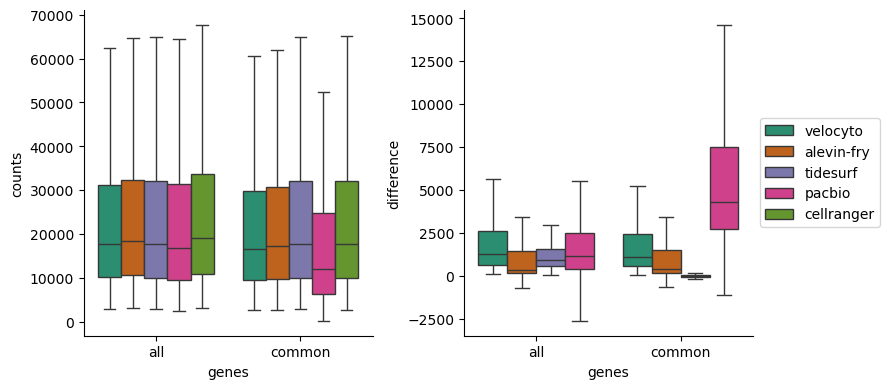

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))

sns.boxplot(
    data=total_counts,
    x="genes",
    y="counts",
    hue="method",
    hue_order=[
        "velocyto", "alevin-fry", "tidesurf", "pacbio", "cellranger"
    ],
    palette="Dark2",
    showfliers=False,
    ax=axs[0]
)
axs[0].get_legend().remove()

sns.boxplot(
    data=counts_diff,
    x="genes",
    y="difference",
    hue="method",
    hue_order=[
        "velocyto", "alevin-fry", "tidesurf", "pacbio"
    ],
    palette="Dark2",
    showfliers=False,
    ax=axs[1]
)

handles, labels = axs[0].get_legend_handles_labels()
axs[1].legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

sns.despine(fig)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "total_counts.png"), dpi=200)

In [13]:
# Spliced and unspliced counts per cell
# Adding ambiguous to spliced for the short read data (no ambiguous for PacBio)
spliced_unspliced_counts = pd.concat(
    [
        pd.DataFrame(
            data={
                "spliced": (
                    np.asarray(adata.layers["spliced"].sum(axis=1)).flatten() +
                    np.asarray(adata.layers["ambiguous"].sum(axis=1)).flatten()
                ) if method != "pacbio" else np.asarray(adata.layers["spliced"].sum(axis=1)).flatten(),
                "unspliced": np.asarray(adata.layers["unspliced"].sum(axis=1)).flatten(),
                "method": method,
                "genes": "all"
            }
        )
        for method, adata in adatas_sub.items()
        if method not in ["cellranger", "pacbio_gene"]
    ] +
    [
        pd.DataFrame(
            data={
                "spliced": (
                    np.asarray(adata.layers["spliced"].sum(axis=1)).flatten() +
                    np.asarray(adata.layers["ambiguous"].sum(axis=1)).flatten()
                ) if method != "pacbio" else np.asarray(adata.layers["spliced"].sum(axis=1)).flatten(),
                "unspliced": np.asarray(adata.layers["unspliced"].sum(axis=1)).flatten(),
                "method": method,
                "genes": "common"
            }
        )
        for method, adata in adatas_common.items()
        if method not in ["cellranger", "pacbio_gene"]
    ]
)

totals = (
    spliced_unspliced_counts["spliced"] +
    spliced_unspliced_counts["unspliced"]
)

spliced_unspliced_ratios = pd.DataFrame(
    data={
        "spliced": spliced_unspliced_counts["spliced"] / totals,
        "unspliced": spliced_unspliced_counts["unspliced"] / totals,
        "genes": spliced_unspliced_counts["genes"],
        "method": spliced_unspliced_counts["method"]
    }
)

spliced_unspliced_counts = spliced_unspliced_counts.melt(
    id_vars=["genes", "method"], var_name="splice_state", value_name="counts"
)
spliced_unspliced_counts.to_parquet(
    os.path.join(
        OUT_DIR, "spliced_unspliced_counts.parquet.gz"
    ), compression="gzip"
)
spliced_unspliced_ratios = spliced_unspliced_ratios.melt(
    id_vars=["genes", "method"], var_name="splice_state", value_name="ratio"
)
spliced_unspliced_ratios.to_parquet(
    os.path.join(
        OUT_DIR, "spliced_unspliced_ratios.parquet.gz"
    ), compression="gzip"
)

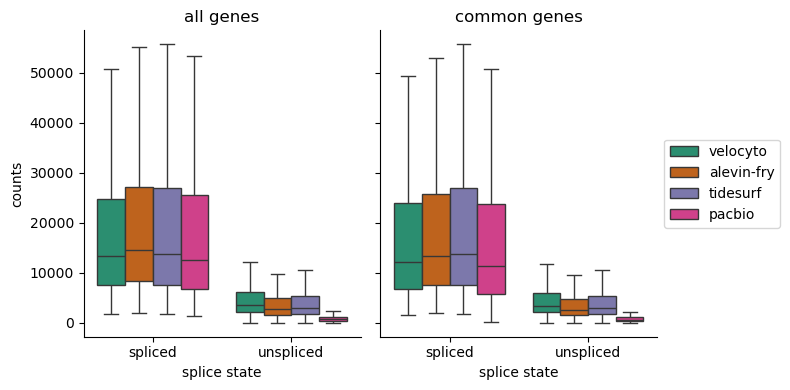

In [14]:
# Boxplots of spliced/unspliced/ambiguous counts
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey="row", sharex=True)

for i, subset in enumerate(["all", "common"]):
    sns.boxplot(
        data=spliced_unspliced_counts[spliced_unspliced_counts["genes"] == subset],
        x="splice_state",
        y="counts",
        hue="method",
        palette="Dark2",
        showfliers=False,
        ax=axs[i]
    )
    axs[i].set_title(f"{subset} genes")
    axs[i].set_xlabel("splice state")
    axs[i].get_legend().remove()

axs[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "spliced_unspliced_counts.png"), dpi=200)

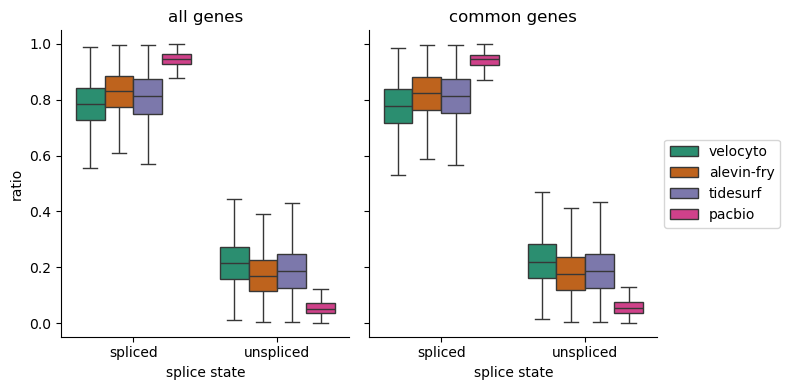

In [15]:
# Boxplots of spliced/unspliced/ambiguous ratios
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey="row", sharex=True)

for i, subset in enumerate(["all", "common"]):
    sns.boxplot(
        data=spliced_unspliced_ratios[spliced_unspliced_ratios["genes"] == subset],
        x="splice_state",
        y="ratio",
        hue="method",
        palette="Dark2",
        showfliers=False,
        ax=axs[i]
    )
    axs[i].set_title(f"{subset} genes")
    axs[i].get_legend().remove()
    axs[i].set_xlabel("splice state")

axs[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "spliced_unspliced_ratios.png"), dpi=200)

In [16]:
spliced_unspliced_ratios[
    spliced_unspliced_ratios["genes"] == "common"
].groupby(["method", "splice_state"]).mean(numeric_only=True)

ratio
method     splice_state          
alevin-fry spliced       0.814292
           unspliced     0.185708
pacbio     spliced       0.932870
           unspliced     0.067130
tidesurf   spliced       0.803369
           unspliced     0.196631
velocyto   spliced       0.768010
           unspliced     0.231990

In [17]:
# Difference of total spliced and unspliced counts from pacbio
spliced_unspliced_sums_pb_all = pd.DataFrame(
    data={
        "spliced": np.asarray(adatas_sub["pacbio"].layers["spliced"].sum(axis=1)).flatten(),
        "unspliced": np.asarray(adatas_sub["pacbio"].layers["unspliced"].sum(axis=1)).flatten(),
    }
)
spliced_unspliced_sums_pb_common = pd.DataFrame(
    data={
        "spliced": np.asarray(adatas_common["pacbio"].layers["spliced"].sum(axis=1)).flatten(),
        "unspliced": np.asarray(adatas_common["pacbio"].layers["unspliced"].sum(axis=1)).flatten(),
    }
)

spliced_unspliced_diff = pd.concat(
    [
        pd.DataFrame(
            data={
                "spliced": (
                    (
                        np.asarray(adatas_sub[method].layers["spliced"].sum(axis=1)).flatten() +
                        np.asarray(adatas_sub[method].layers["ambiguous"].sum(axis=1)).flatten()
                    )
                    - spliced_unspliced_sums_pb_all["spliced"]
                ),
                "unspliced": (
                    np.asarray(adatas_sub[method].layers["unspliced"].sum(axis=1)).flatten()
                    - spliced_unspliced_sums_pb_all["unspliced"]
                ),
                "genes": "all",
                "method": method
            }
        )
        for method in ["velocyto", "alevin-fry", "tidesurf"]
    ] + 
    [
        pd.DataFrame(
            data={
                "spliced": (
                    (
                        np.asarray(adatas_common[method].layers["spliced"].sum(axis=1)).flatten() +
                        np.asarray(adatas_common[method].layers["ambiguous"].sum(axis=1)).flatten()
                    )
                    - spliced_unspliced_sums_pb_all["spliced"]
                ),
                "unspliced": (
                    np.asarray(adatas_common[method].layers["unspliced"].sum(axis=1)).flatten()
                    - spliced_unspliced_sums_pb_all["unspliced"]
                ),
                "genes": "common",
                "method": method
            }
        )
        for method in ["velocyto", "alevin-fry", "tidesurf"]
    ]
).melt(
    id_vars=["genes", "method"], var_name="splice_state", value_name="diff"
)
spliced_unspliced_diff.to_parquet(
    os.path.join(
        OUT_DIR, "spliced_unspliced_diff.parquet.gz"
    ), compression="gzip"
)

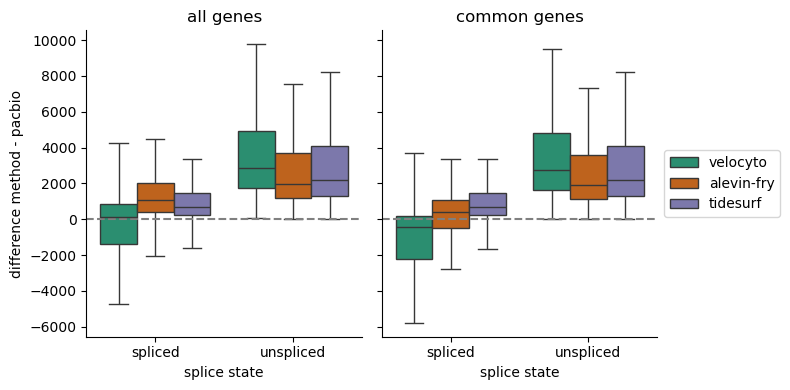

In [18]:
# Boxplots of spliced and unspliced count differences from pacbio
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey="row", sharex=True)

for i, subset in enumerate(["all", "common"]):
    sns.boxplot(
        data=spliced_unspliced_diff[spliced_unspliced_diff["genes"] == subset],
        x="splice_state",
        y="diff",
        hue="method",
        palette="Dark2",
        showfliers=False,
        ax=axs[i]
    )
    axs[i].set_title(f"{subset} genes")
    axs[i].set_xlabel("splice state")
    axs[i].set_ylabel("difference method - pacbio")
    axs[i].get_legend().remove()
    axs[i].axhline(color="grey", linestyle="--")

axs[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "spliced_unspliced_diff.png"), dpi=200)

In [19]:
# Pearson correlation of spliced and unspliced counts per gene with pacbio
counts_corr = pd.concat(
    [
        pd.DataFrame(
            data={
                "method": method,
                "spliced": stats.pearsonr(
                    (
                        adata.layers["spliced"].toarray() +
                        adata.layers["ambiguous"].toarray()
                    ),
                    adatas_common["pacbio"].layers["spliced"].toarray(),
                    axis=0
                )[0],
                "unspliced": stats.pearsonr(
                    adata.layers["unspliced"].toarray(),
                    adatas_common["pacbio"].layers["unspliced"].toarray(),
                    axis=0
                )[0],
            }
        )
        for method, adata in adatas_common.items()
        if method not in ["cellranger", "pacbio", "pacbio_gene"]
    ]
).melt(
    id_vars="method", var_name="splice_state", value_name="pearsonr"
)
counts_corr.to_parquet(
    os.path.join(
        OUT_DIR, "spliced_unspliced_corr_pb.parquet.gz"
    ), compression="gzip"
)

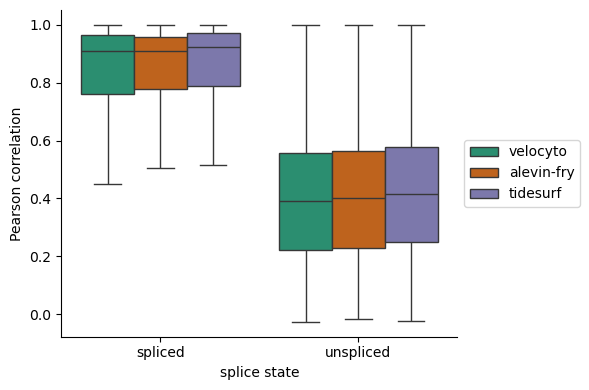

In [20]:
# Boxplots of correlations for spliced/unspliced/ambiguous counts
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=counts_corr,
    x="splice_state",
    y="pearsonr",
    hue="method",
    palette="Dark2",
    showfliers=False,
    ax=ax
)
ax.set_xlabel("splice state")
ax.set_ylabel("Pearson correlation")

ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "spliced_unspliced_corr_pb.png"), dpi=200)

In [21]:
# Cosine similarity of spliced/unspliced/ambiguous counts per cell
counts_cosine = pd.concat(
    [
        pd.DataFrame(
            data={
                "method": method,
                "spliced": np.diagonal(
                    cosine_similarity(
                        (
                            adata.layers["spliced"].toarray() +
                            adata.layers["ambiguous"].toarray()
                        ),
                        adatas_common["pacbio"].layers["spliced"].toarray(),
                    )
                ),
                "unspliced": np.diagonal(
                    cosine_similarity(
                        adata.layers["unspliced"].toarray(),
                        adatas_common["pacbio"].layers["unspliced"].toarray(),
                    )
                ),
            }
        )
        for method, adata in adatas_common.items()
        if method not in ["cellranger", "pacbio", "pacbio_gene"]
    ]
).melt(
    id_vars="method", var_name="splice_state", value_name="cosine_similarity"
)
counts_cosine.to_parquet(
    os.path.join(
        OUT_DIR, "spliced_unspliced_cosine_pb.parquet.gz"
    ), compression="gzip"
)

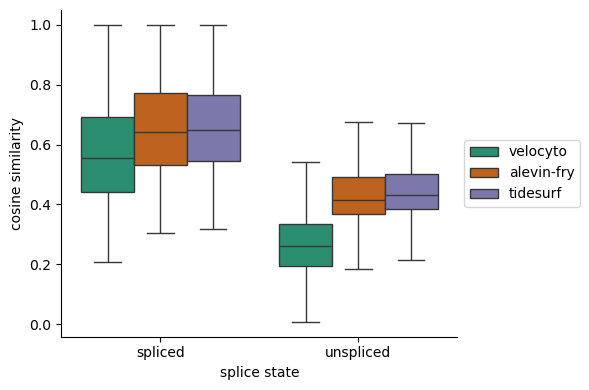

In [22]:
# Boxplots of cosine similarities for spliced/unspliced/ambiguous counts
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=counts_cosine,
    x="splice_state",
    y="cosine_similarity",
    hue="method",
    palette="Dark2",
    showfliers=False,
    ax=ax
)
ax.set_xlabel("splice state")
ax.set_ylabel("cosine similarity")

ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "spliced_unspliced_cosine_pb.png"), dpi=200)

In [23]:
# Pearson correlation with pacbio per gene
counts_corr_pb = pd.concat(
    [
        pd.DataFrame(
            data={
                "method": method,
                "pearsonr": stats.pearsonr(
                    (
                        adata.layers["spliced"] +
                        adata.layers["unspliced"] +
                        adata.layers["ambiguous"]
                    ).toarray()
                    if method == "velocyto"
                    else adata.X.toarray(),
                    adatas_common["pacbio_gene"].X.toarray(),
                    axis=0
                )[0]
            }
        )
        for method, adata in adatas_common.items()
        if method != "pacbio_gene"
    ]
).reset_index(drop=True)
counts_corr_pb.to_parquet(
    os.path.join(
        OUT_DIR, "counts_corr_pacbio.parquet.gz"
    ), compression="gzip"
)

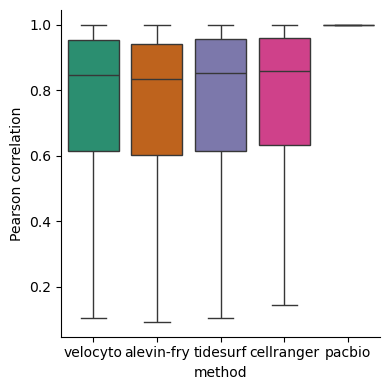

In [24]:
# Boxplots of correlations with pacbio
fig, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(
    data=counts_corr_pb,
    x="method",
    y="pearsonr",
    hue="method",
    palette="Dark2",
    showfliers=False,
    ax=ax
)
ax.set_ylabel("Pearson correlation")


sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "counts_corr_pb.png"), dpi=200)

In [25]:
# Cosine similarity with pacbio per cell
counts_cosine_pb = pd.concat(
    [
        pd.DataFrame(
            data={
                "method": method,
                "cosine_similarity": np.diagonal(
                    cosine_similarity(
                        (
                            adata.layers["spliced"] +
                            adata.layers["unspliced"] +
                            adata.layers["ambiguous"]
                        ).toarray()
                        if method == "velocyto"
                        else adata.X.toarray(),
                        adatas_common["pacbio_gene"].X.toarray()
                    )
                )
            }
        )
        for method, adata in adatas_common.items()
        if method != "pacbio_gene"
    ]
).reset_index(drop=True)
counts_cosine_pb.to_parquet(
    os.path.join(
        OUT_DIR, "counts_cosine_pacbio.parquet.gz"
    ), compression="gzip"
)

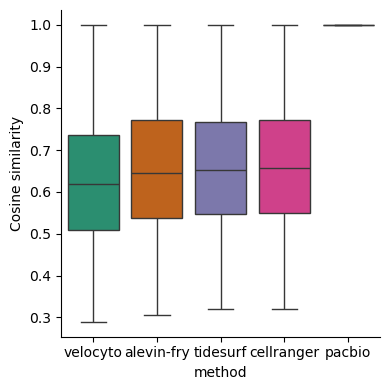

In [26]:
# Boxplots of cosine similarities with pacbio
fig, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(
    data=counts_cosine_pb,
    x="method",
    y="cosine_similarity",
    hue="method",
    palette="Dark2",
    showfliers=False,
    ax=ax
)
ax.set_ylabel("Cosine similarity")


sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "counts_cosine_pacbio.png"), dpi=200)

In [27]:
# Euclidean distance from PacBio per cell
counts_euclidean_pb = pd.concat(
    [
        pd.DataFrame(
            data={
                "method": method,
                "euclidean_distance": np.diagonal(
                    euclidean_distances(
                        (
                            adata.layers["spliced"] +
                            adata.layers["unspliced"] +
                            adata.layers["ambiguous"]
                        ).toarray()
                        if method == "velocyto"
                        else adata.X.toarray(),
                        adatas_common["pacbio_gene"].X.toarray()
                    )
                )
            }
        )
        for method, adata in adatas_common.items()
        if method != "pacbio_gene"
    ]
).reset_index(drop=True)
counts_euclidean_pb.to_parquet(
    os.path.join(
        OUT_DIR, "counts_euclidean_pacbio.parquet.gz"
    ), compression="gzip"
)

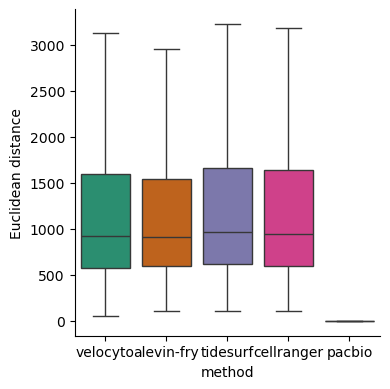

In [28]:
# Boxplots of Euclidean distances with PacBio
fig, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(
    data=counts_euclidean_pb,
    x="method",
    y="euclidean_distance",
    hue="method",
    palette="Dark2",
    showfliers=False,
    ax=ax
)
ax.set_ylabel("Euclidean distance")


sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "counts_euclidean_pacbio.png"), dpi=200)

## Molecule comparison

Comparing splice state for individual molecules between PacBio data and tidesurf quantification.

In [29]:
molecule_info =  pd.concat(
    {
        re.search(
            "/pacbio/filtered/(.*)/matrices/scisoseq.annotated.info.csv", file
        ).group(1): pd.read_csv(file, sep="\t")
        for file in glob.glob(
            os.path.join(DATA_DIR, "pacbio/filtered/*/matrices/scisoseq.annotated.info.csv")
        )
    },
    names=["sample", "index"],
).reset_index().drop(
    columns=["index", "id", "pbid", "length", "ontarget", "ORFgroup", "UMI", "BC", "pass_pigeon_filter"]
).rename(columns={"UMIrev": "umi", "BCrev": "cbc"})

In [30]:
molecule_info

,sample,transcript,gene,category,umi,cbc
0,G16_315_ccRCC,novel,novelGene_ENSG00000241860_AS,antisense,GTAATCGTACTC,TTCGCTGCACGCCACA
1,G16_315_ccRCC,novel,novelGene_ENSG00000241860_AS,antisense,CTACGGGACTCT,GTGTTCCTCTGCAGCG
2,G16_315_ccRCC,novel,novelGene_ENSG00000241860_AS,antisense,AGGGACCAGGTT,CCCATTGCATATCGGT
3,G16_315_ccRCC,novel,novelGene_ENSG00000241860_AS,antisense,AGTAACCTCTTC,TCAATTCCAACGATCT
4,G16_315_ccRCC,novel,novelGene_ENSG00000241860_AS,antisense,CAGTTGATGCTG,CATTGCCAGAAGATCT
...,...,...,...,...,...,...
72498831,G18_626_Normal,novel,novelGene_727303,intergenic,GATTTATTAATA,TGAACGTGTATCCCAA
72498832,G18_626_Normal,novel,novelGene_727303,intergenic,ACAGTGGGTGTT,CACGGGTAGCGAACTG
72498833,G18_626_Normal,novel,novelGene_727303,intergenic,TAGCACGGTATG,GTCCCATAGCCATTCA
72498834,G18_626_Normal,novel,novelGene_727303,intergenic,GACGGGCCGTCC,CAGAGCCAGATTAGAC


In [31]:
umi_df_tidesurf = pd.concat(
    {
        re.search(
            "tidesurf/(.*)/umi_tables_per_cell", folder
        ).group(1): pd.concat(
            {
                re.search(
                    "umi_table_single_gene_([ACTG]+)-1.parquet", file
                ).group(1): pd.read_parquet(file)
                for file in glob.glob(os.path.join(folder, "umi_table_single_gene_*.parquet"))
            },
            names=["cbc", "index"]
        ).reset_index().drop(columns="index")
        for folder in glob.glob(
            os.path.join(DATA_DIR, "tidesurf/*/umi_tables_per_cell")
        )
    },
    names=["sample", "index"]
).reset_index().drop(columns="index")
umi_df_tidesurf

,sample,cbc,umi,gene,total,splice_type,idx
0,G16_315_ccRCC,ACGATGTAGGTTCATC,AGGGCCATGGTG,ACTR3C,[1.0],0,0
1,G16_315_ccRCC,ACGATGTAGGTTCATC,GCAGGATTTATG,INVS,[5.0],0,0
2,G16_315_ccRCC,ACGATGTAGGTTCATC,GTTTAGCGACTA,KCNIP4,[3.0],0,0
3,G16_315_ccRCC,ACGATGTAGGTTCATC,CCGTCTAACAAG,MT-CO1,[7.0],2,0
4,G16_315_ccRCC,ACGATGTAGGTTCATC,TACTAACCAGGG,RALGAPB,[3.0],0,0
...,...,...,...,...,...,...,...
62435775,G18_626_Normal,TTTGACTCATTGGCAT,TGGTAACAAACC,FTH1,[3.0],1,0
62435776,G18_626_Normal,TTTGACTCATTGGCAT,AACCTTCCTGGC,STC1,[1.0],2,0
62435777,G18_626_Normal,TTTGACTCATTGGCAT,ACCGTATCCGCA,KYAT3,[2.0],0,0
62435778,G18_626_Normal,TTTGACTCATTGGCAT,CGATCCCATTTG,TACC1,[3.0],1,0


tidesurf splice types:
- 0: unspliced
- 1: ambiguous
- 2: spliced

In [32]:
comp_df = molecule_info.merge(umi_df_tidesurf, on=["sample", "cbc", "umi"], how="outer")
comp_df["splice_type_str"] = comp_df["splice_type"].map({0.0: "unspliced", 1.0: "ambiguous", 2.0: "spliced"})
comp_df[["category", "splice_type_str"]] = comp_df[["category", "splice_type_str"]].fillna("not contained")
comp_df

,sample,transcript,gene_x,category,umi,cbc,gene_y,total,splice_type,idx,splice_type_str
0,G16_315_ccRCC,novel,novelGene_382804,intergenic,AAAAAAAGGGAG,AAACCCAGTATGAGCG,CRTC1,[4.0],0.0,0.0,unspliced
1,G16_315_ccRCC,novel,MT-CO3+MT-RNR1,genic,AAAAAAATCTGG,AAACCCAGTATGAGCG,MT-CO3,[5.0],2.0,0.0,spliced
2,G16_315_ccRCC,novel,novelGene_4757,intergenic,AAAAAAATTCAG,AAACCCAGTATGAGCG,DHRS3,[4.0],0.0,0.0,unspliced
3,G16_315_ccRCC,ENST00000389680.2,MT-RNR1,full-splice_match,AAAAAACTTATC,AAACCCAGTATGAGCG,NaN,NaN,NaN,NaN,not contained
4,G16_315_ccRCC,novel,novelGene_664155,intergenic,AAAAAATCGGCC,AAACCCAGTATGAGCG,POLK,[2.0],0.0,0.0,unspliced
...,...,...,...,...,...,...,...,...,...,...,...
75567286,G18_626_ccRCC,novel,novelGene_210584,intergenic,TTTTTTTAAAAT,TTTGTTGTCCAACTAG,TVP23B,[11.0],0.0,0.0,unspliced
75567287,G18_626_ccRCC,ENST00000494573.6,LDHA,full-splice_match,TTTTTTTAAGCT,TTTGTTGTCCAACTAG,LDHA,[8.0],0.0,0.0,unspliced
75567288,G18_626_ccRCC,ENST00000494573.6,LDHA,full-splice_match,TTTTTTTAAGCT,TTTGTTGTCCAACTAG,LDHA,[8.0],0.0,0.0,unspliced
75567289,G18_626_ccRCC,ENST00000494573.6,LDHA,full-splice_match,TTTTTTTAAGCT,TTTGTTGTCCAACTAG,LDHA,[8.0],0.0,0.0,unspliced


In [33]:
cont_mat = pd.DataFrame(
    contingency_matrix(comp_df["category"], comp_df["splice_type_str"]),
    index=sorted(comp_df["category"].unique()),
    columns=sorted(comp_df["splice_type_str"].unique()),
)
cont_mat

,ambiguous,not contained,spliced,unspliced
antisense,4452,1258869,21614,240455
full-splice_match,3052371,5263983,24123282,377111
fusion,186561,59722,346539,10705
genic,135402,1130926,10215152,1687430
genic_intron,3,342,29,3880
incomplete-splice_match,709678,449488,5482086,683946
intergenic,13867,3622102,72090,6283776
moreJunctions,219,223,2443,156
not contained,211528,0,1924011,932916
novel_in_catalog,126767,172672,1161008,89247


In [35]:
assert np.all(
    comp_df["category"].value_counts()[cont_mat.index] == cont_mat.sum(axis=1)
)
assert np.all(
    comp_df["splice_type_str"].value_counts()[cont_mat.columns] == cont_mat.sum(axis=0)
)

In [36]:
cont_mat_row_norm = cont_mat.div(cont_mat.sum(axis=1), axis=0)
cont_mat_col_norm = cont_mat.div(cont_mat.sum(axis=0), axis=1)

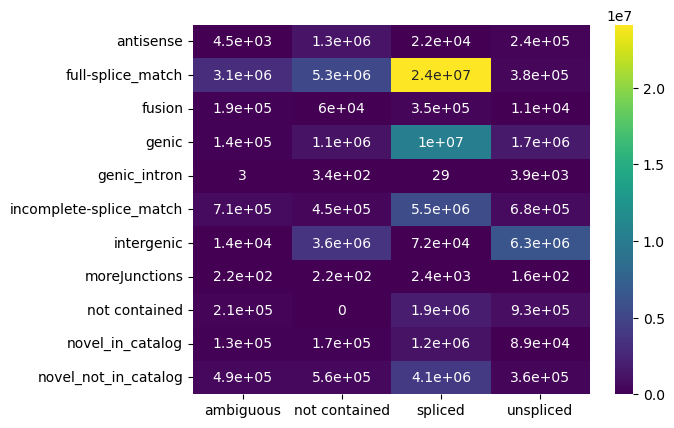

In [41]:
sns.heatmap(cont_mat, cmap="viridis", annot=True)
plt.savefig(
    os.path.join(FIG_DIR, "molecules_contingency_matrix.png"),
    dpi=200,
    bbox_inches="tight",
)

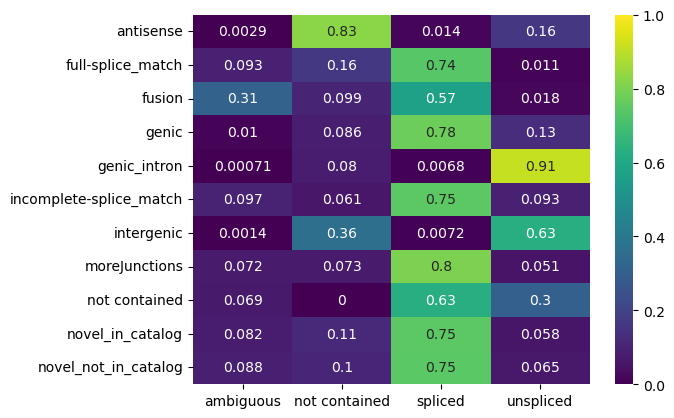

In [42]:
sns.heatmap(cont_mat_row_norm, cmap="viridis", annot=True, vmin=0, vmax=1)
plt.savefig(
    os.path.join(FIG_DIR, "molecules_contingency_matrix_normalized_pb.png"), 
    dpi=200,
    bbox_inches="tight",
)

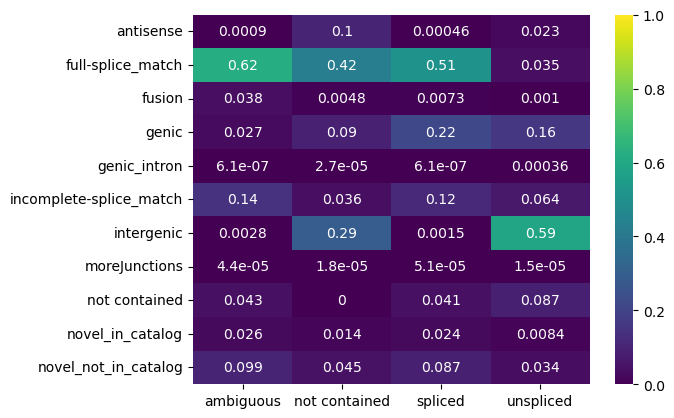

In [44]:
sns.heatmap(cont_mat_col_norm, cmap="viridis", annot=True, vmin=0, vmax=1)
plt.savefig(
    os.path.join(FIG_DIR, "molecules_contingency_matrix_normalized_ts.png"),
    dpi=200,
    bbox_inches="tight",
)

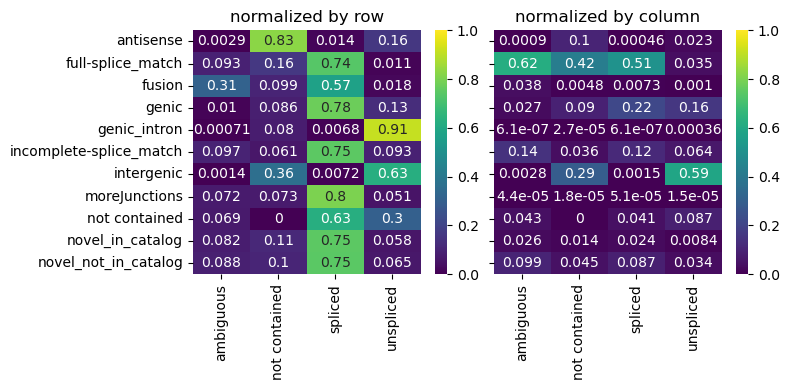

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True, layout="tight")
sns.heatmap(
    cont_mat_row_norm, cmap="viridis", annot=True, vmin=0, vmax=1, ax=axs[0]
)
axs[0].set_title("normalized by row")
sns.heatmap(
    cont_mat_col_norm, cmap="viridis", annot=True, vmin=0, vmax=1, ax=axs[1]
)
axs[1].set_title("normalized by column")
fig.savefig(
    os.path.join(FIG_DIR, "molecules_contingency_matrices_normalized.png"), dpi=200
)

In [40]:
comp_df.to_parquet(
    os.path.join(
        OUT_DIR, "molecule_comparison.parquet.gz"
    ), compression="gzip"
)
cont_mat.to_parquet(
    os.path.join(
        OUT_DIR, "molecule_contingency_matrix.parquet.gz"
    ), compression="gzip"
)